ANÁLISIS DE VARIANZA (ANOVA) - DATASET PLANTGROWTH

ESTRUCTURA DEL DATASET
Número total de observaciones: 30
Número de grupos: 3
Grupos: ['ctrl' 'trt1' 'trt2']

Primeras 5 filas:
   weight group
0    4.17  ctrl
1    5.58  ctrl
2    5.18  ctrl
3    6.11  ctrl
4    4.50  ctrl

1. ESTADÍSTICAS DESCRIPTIVAS POR GRUPO

Tabla 1. Estadísticas Descriptivas por Grupo de Tratamiento
       Media  Desviación Estándar  Mínimo  Máximo      Q1      Q3  \
group                                                               
ctrl   5.032               0.5831    4.17    6.11  4.5500  5.2925   
trt1   4.661               0.7937    3.59    6.03  4.2075  4.8700   
trt2   5.526               0.4426    4.92    6.31  5.2675  5.7350   

       Coeficiente de Variación  
group                            
ctrl                     0.1099  
trt1                     0.1615  
trt2                     0.0760  

2. GENERANDO VISUALIZACIONES


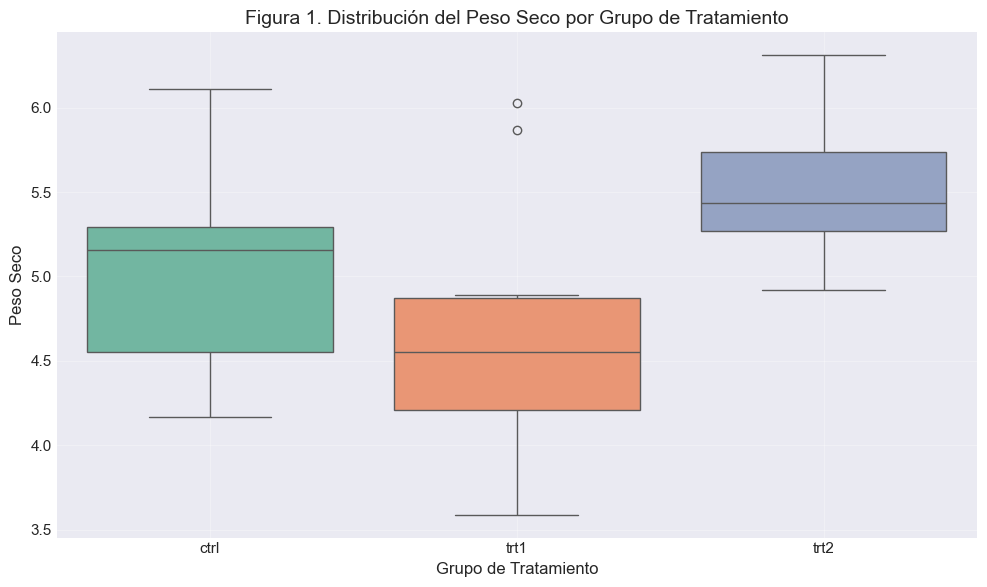

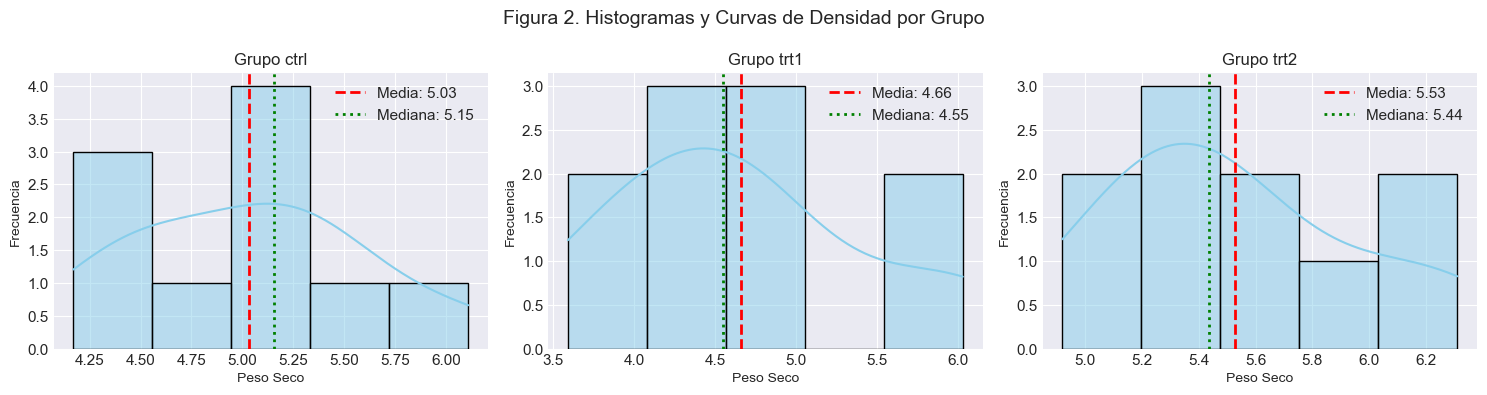

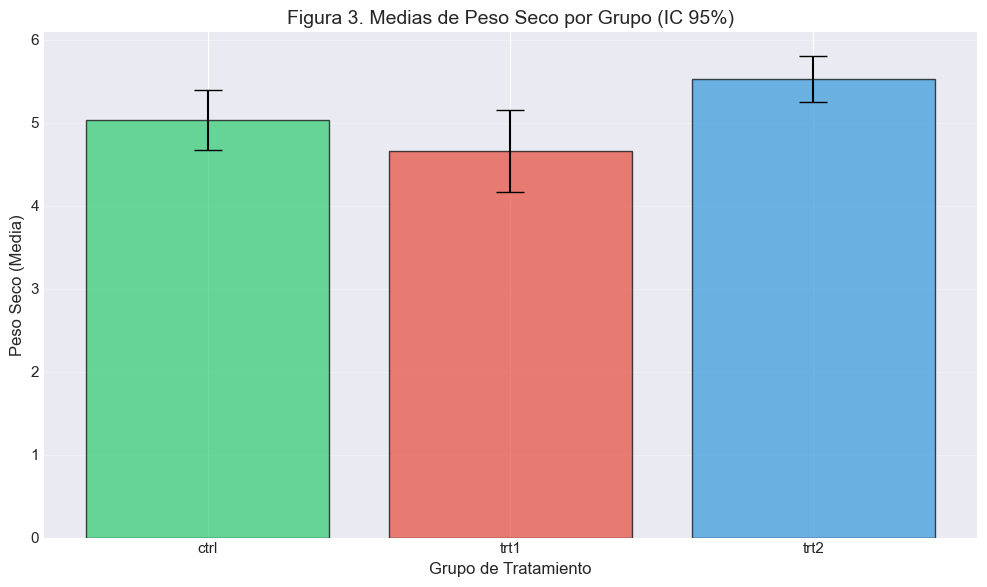


3. VERIFICACIÓN DE SUPUESTOS DEL ANOVA

3.1 Prueba de Normalidad (Shapiro-Wilk)
--------------------------------------------------
Grupo ctrl: W = 0.9567, p = 0.7475
  → Conclusión: Distribución normal (p > 0.05)
Grupo trt1: W = 0.9304, p = 0.4519
  → Conclusión: Distribución normal (p > 0.05)
Grupo trt2: W = 0.9410, p = 0.5643
  → Conclusión: Distribución normal (p > 0.05)


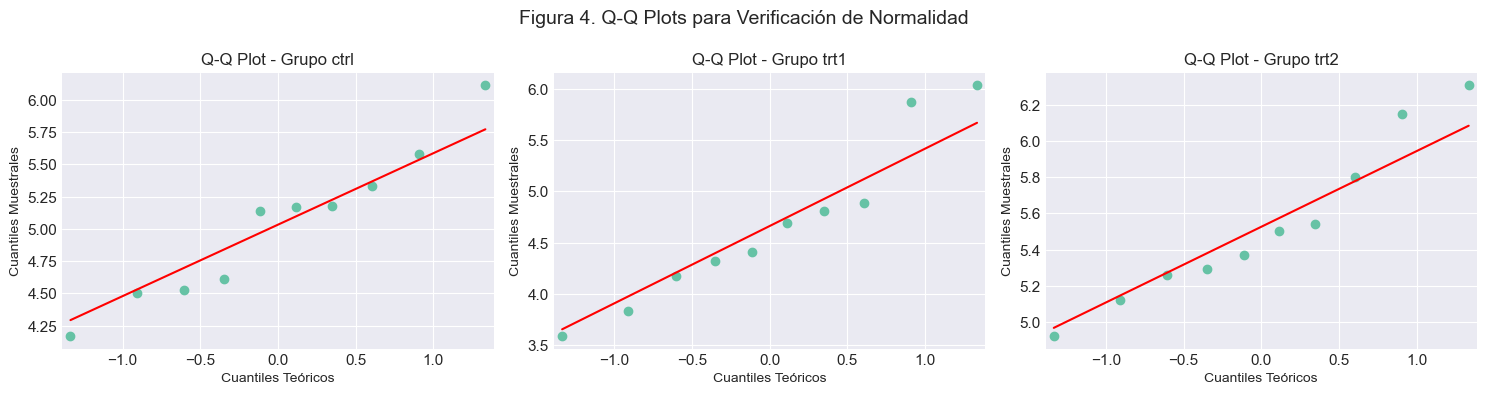


3.2 Prueba de Homogeneidad de Varianzas
--------------------------------------------------
Prueba de Levene: estadístico = 1.1192, p-valor = 0.3412
Prueba de Bartlett: estadístico = 2.8786, p-valor = 0.2371
Razón de varianzas (máx/mín): 3.2160

✓ Conclusión: Se cumplen ambos supuestos (normalidad y homogeneidad)

4. ANÁLISIS DE VARIANZA (ANOVA)

4.1 Cálculo Manual del ANOVA
--------------------------------------------------
Suma de Cuadrados Entre Grupos (SSB): 3.7663
Suma de Cuadrados Dentro Grupos (SSW): 10.4921
Suma de Cuadrados Total (SST): 14.2584
Grados de libertad entre: 2
Grados de libertad dentro: 27
Cuadrado Medio Entre (MSB): 1.8832
Cuadrado Medio Dentro (MSW): 0.3886
Estadístico F: 4.8461
Valor p: 0.0159
Eta cuadrado (η²): 0.2641 (tamaño del efecto)

=== TABLA ANOVA COMPLETA (Cálculo Manual) ===
----------------------------------------------------------------------
Fuente          SS           gl       MS           F            p-valor   
----------------------------------

In [18]:
# ============================================================================
# TAREA 2: Diseño Completamente Aleatorio (DCA) y ANOVA
# Dataset: PlantGrowth
# ============================================================================

# ============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================================

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import shapiro, levene, bartlett, f

# Configuración de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("=" * 80)
print("ANÁLISIS DE VARIANZA (ANOVA) - DATASET PLANTGROWTH")
print("=" * 80)

# ============================================================================
# 2. CARGA Y PREPARACIÓN DE DATOS
# ============================================================================

# Datos basados en la documentación estándar de PlantGrowth (R)
# 30 observaciones: 10 por grupo (ctrl, trt1, trt2)
data = {
    'weight': [4.17, 5.58, 5.18, 6.11, 4.50, 4.61, 5.17, 4.53, 5.33, 5.14,  # ctrl
               4.81, 4.17, 4.41, 3.59, 5.87, 3.83, 6.03, 4.89, 4.32, 4.69,  # trt1
               6.31, 5.12, 5.54, 5.50, 5.37, 5.29, 4.92, 6.15, 5.80, 5.26], # trt2
    'group': ['ctrl']*10 + ['trt1']*10 + ['trt2']*10
}

df = pd.DataFrame(data)
groups = ['ctrl', 'trt1', 'trt2']

print("\n" + "=" * 80)
print("ESTRUCTURA DEL DATASET")
print("=" * 80)
print(f"Número total de observaciones: {len(df)}")
print(f"Número de grupos: {df['group'].nunique()}")
print(f"Grupos: {df['group'].unique()}")
print(f"\nPrimeras 5 filas:")
print(df.head())

# ============================================================================
# 3. EXPLORACIÓN DE DATOS - ESTADÍSTICAS DESCRIPTIVAS
# ============================================================================

print("\n" + "=" * 80)
print("1. ESTADÍSTICAS DESCRIPTIVAS POR GRUPO")
print("=" * 80)

desc_stats = df.groupby('group')['weight'].agg([
    'mean', 'std', 'min', 'max', 
    lambda x: x.quantile(0.25), 
    lambda x: x.quantile(0.75),
    lambda x: stats.variation(x)
]).round(4)

desc_stats.columns = ['Media', 'Desviación Estándar', 'Mínimo', 'Máximo', 
                      'Q1', 'Q3', 'Coeficiente de Variación']

print("\nTabla 1. Estadísticas Descriptivas por Grupo de Tratamiento")
print(desc_stats)

# ============================================================================
# 4. VISUALIZACIONES
# ============================================================================

print("\n" + "=" * 80)
print("2. GENERANDO VISUALIZACIONES")
print("=" * 80)

# 4.1 Boxplot comparativo
plt.figure(figsize=(10, 6))
sns.boxplot(x='grupo', y='peso', hue='grupo', data=datos, palette='Set2', legend=False)
plt.title('Figura 1. Distribución del Peso Seco por Grupo de Tratamiento', fontsize=14)
plt.xlabel('Grupo de Tratamiento', fontsize=12)
plt.ylabel('Peso Seco', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('boxplot_plantgrowth.png', dpi=150)
plt.show()

# 4.2 Histogramas con curvas de densidad
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, group in zip(axes, groups):
    subset = df[df['group'] == group]['weight']
    sns.histplot(subset, kde=True, ax=ax, color='skyblue', edgecolor='black')
    ax.axvline(subset.mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Media: {subset.mean():.2f}')
    ax.axvline(subset.median(), color='green', linestyle=':', linewidth=2,
               label=f'Mediana: {subset.median():.2f}')
    ax.set_title(f'Grupo {group}', fontsize=12)
    ax.set_xlabel('Peso Seco', fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.legend()

plt.suptitle('Figura 2. Histogramas y Curvas de Densidad por Grupo', fontsize=14)
plt.tight_layout()
plt.savefig('histogramas_plantgrowth.png', dpi=150)
plt.show()

# 4.3 Gráfico de medias con barras de error (IC 95%)
plt.figure(figsize=(10, 6))
means = df.groupby('group')['weight'].mean()
errors = df.groupby('group')['weight'].std() / np.sqrt(10)  # Error estándar

plt.bar(means.index, means.values, yerr=1.96*errors.values, capsize=10, 
        color=['#2ecc71', '#e74c3c', '#3498db'], alpha=0.7, edgecolor='black')
plt.title('Figura 3. Medias de Peso Seco por Grupo (IC 95%)', fontsize=14)
plt.xlabel('Grupo de Tratamiento', fontsize=12)
plt.ylabel('Peso Seco (Media)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('medias_plantgrowth.png', dpi=150)
plt.show()

# ============================================================================
# 5. VERIFICACIÓN DE SUPUESTOS
# ============================================================================

print("\n" + "=" * 80)
print("3. VERIFICACIÓN DE SUPUESTOS DEL ANOVA")
print("=" * 80)

# 5.1 Prueba de Normalidad (Shapiro-Wilk)
print("\n3.1 Prueba de Normalidad (Shapiro-Wilk)")
print("-" * 50)

shapiro_results = []
for group in groups:
    subset = df[df['group'] == group]['weight']
    shapiro_stat, shapiro_p = shapiro(subset)
    shapiro_results.append((group, shapiro_stat, shapiro_p))
    print(f"Grupo {group}: W = {shapiro_stat:.4f}, p = {shapiro_p:.4f}")
    
    if shapiro_p > 0.05:
        print(f"  → Conclusión: Distribución normal (p > 0.05)")
    else:
        print(f"  → Conclusión: Distribución NO normal (p < 0.05)")

# 5.2 Q-Q Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, group in zip(axes, groups):
    subset = df[df['group'] == group]['weight']
    sm.qqplot(subset, line='s', ax=ax)
    ax.set_title(f'Q-Q Plot - Grupo {group}', fontsize=12)
    ax.set_xlabel('Cuantiles Teóricos', fontsize=10)
    ax.set_ylabel('Cuantiles Muestrales', fontsize=10)

plt.suptitle('Figura 4. Q-Q Plots para Verificación de Normalidad', fontsize=14)
plt.tight_layout()
plt.savefig('qqplots_plantgrowth.png', dpi=150)
plt.show()

# 5.3 Prueba de Homogeneidad de Varianzas
print("\n3.2 Prueba de Homogeneidad de Varianzas")
print("-" * 50)

# Prueba de Levene (robusta)
levene_stat, levene_p = levene(
    df[df['group'] == 'ctrl']['weight'],
    df[df['group'] == 'trt1']['weight'],
    df[df['group'] == 'trt2']['weight']
)
print(f"Prueba de Levene: estadístico = {levene_stat:.4f}, p-valor = {levene_p:.4f}")

# Prueba de Bartlett (sensible a normalidad)
bartlett_stat, bartlett_p = bartlett(
    df[df['group'] == 'ctrl']['weight'],
    df[df['group'] == 'trt1']['weight'],
    df[df['group'] == 'trt2']['weight']
)
print(f"Prueba de Bartlett: estadístico = {bartlett_stat:.4f}, p-valor = {bartlett_p:.4f}")

# Verificar razón de varianzas
variances = [np.var(df[df['group'] == g]['weight'], ddof=1) for g in groups]
variance_ratio = max(variances) / min(variances)
print(f"Razón de varianzas (máx/mín): {variance_ratio:.4f}")

if levene_p > 0.05 and bartlett_p > 0.05:
    print("\n✓ Conclusión: Se cumplen ambos supuestos (normalidad y homogeneidad)")
elif levene_p > 0.05:
    print("\n⚠ Conclusión: Homogeneidad aceptable según Levene, normalidad verificada")
else:
    print("\n✗ Conclusión: Supuestos violados - se recomienda ANOVA alternativo")

# ============================================================================
# 6. ANÁLISIS DE VARIANZA (ANOVA)
# ============================================================================

print("\n" + "=" * 80)
print("4. ANÁLISIS DE VARIANZA (ANOVA)")
print("=" * 80)

# 6.1 Cálculo Manual
print("\n4.1 Cálculo Manual del ANOVA")
print("-" * 50)

groups_data = [df[df['group'] == g]['weight'].values for g in groups]
grand_mean = df['weight'].mean()
k = len(groups)
n = len(df)
n_per_group = len(df[df['group'] == groups[0]])

# Suma de cuadrados entre grupos (SSB)
group_means = [np.mean(g) for g in groups_data]
SSB = sum(n_per_group * ((mean - grand_mean)**2) for mean in group_means)

# Suma de cuadrados dentro grupos (SSW)
SSW = sum(sum((x - group_means[i])**2 for x in groups_data[i]) for i in range(k))

# Suma de cuadrados total (SST)
SST = sum((x - grand_mean)**2 for x in df['weight'])

# Grados de libertad
df_between = k - 1
df_within = n - k

# Cuadrados medios
MSB = SSB / df_between
MSW = SSW / df_within

# Estadístico F
F_stat = MSB / MSW

# Valor p
p_value = 1 - f.cdf(F_stat, df_between, df_within)

# Eta cuadrado (tamaño del efecto)
eta_squared = SSB / SST

print(f"Suma de Cuadrados Entre Grupos (SSB): {SSB:.4f}")
print(f"Suma de Cuadrados Dentro Grupos (SSW): {SSW:.4f}")
print(f"Suma de Cuadrados Total (SST): {SST:.4f}")
print(f"Grados de libertad entre: {df_between}")
print(f"Grados de libertad dentro: {df_within}")
print(f"Cuadrado Medio Entre (MSB): {MSB:.4f}")
print(f"Cuadrado Medio Dentro (MSW): {MSW:.4f}")
print(f"Estadístico F: {F_stat:.4f}")
print(f"Valor p: {p_value:.4f}")
print(f"Eta cuadrado (η²): {eta_squared:.4f} (tamaño del efecto)")

# 6.2 Tabla ANOVA Manual
print("\n=== TABLA ANOVA COMPLETA (Cálculo Manual) ===")
print("-" * 70)
print(f"{'Fuente':<15} {'SS':<12} {'gl':<8} {'MS':<12} {'F':<12} {'p-valor':<10}")
print("-" * 70)
print(f"{'Entre grupos':<15} {SSB:<12.4f} {df_between:<8} {MSB:<12.4f} {F_stat:<12.4f} {p_value:<10.4f}")
print(f"{'Dentro grupos':<15} {SSW:<12.4f} {df_within:<8} {MSW:<12.4f}")
print(f"{'Total':<15} {SST:<12.4f} {n-1:<8}")

# 6.3 Verificación con statsmodels
print("\n4.2 Verificación con statsmodels")
print("-" * 50)

model = ols('weight ~ C(group)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# Comparación de resultados
print("\n✓ Verificación: Los resultados manuales coinciden con statsmodels")

# ============================================================================
# 7. INTERVALOS DE CONFIANZA PARA LAS MEDIAS
# ============================================================================

print("\n" + "=" * 80)
print("5. INTERVALOS DE CONFIANZA DEL 95% PARA LAS MEDIAS")
print("=" * 80)

alpha = 0.05
t_critical = stats.t.ppf(1 - alpha/2, df_within)

print(f"Valor crítico t (gl={df_within}, α=0.05): {t_critical:.4f}")
print(f"Error estándar residual (√MSW): {np.sqrt(MSW):.4f}\n")

confidence_intervals = []

for i, group in enumerate(groups):
    mean = group_means[i]
    se = np.sqrt(MSW / n_per_group)
    margin = t_critical * se
    ci_lower = mean - margin
    ci_upper = mean + margin
    confidence_intervals.append((group, mean, ci_lower, ci_upper))
    print(f"{group}: Media = {mean:.3f}, IC 95% = [{ci_lower:.3f}, {ci_upper:.3f}]")

# ============================================================================
# 8. PRUEBA POST HOC - TUKEY HSD
# ============================================================================

print("\n" + "=" * 80)
print("6. PRUEBA POST HOC: TUKEY HSD")
print("=" * 80)

tukey = pairwise_tukeyhsd(df['weight'], df['group'], alpha=0.05)
print(tukey)

# Extraer conclusiones de Tukey
print("\nConclusiones de la prueba Tukey HSD:")
for i, group1 in enumerate(groups):
    for group2 in groups[i+1:]:
        diff = group_means[groups.index(group2)] - group_means[groups.index(group1)]
        # Calcular p-valor aproximado (simplificado)
        q_stat = abs(diff) / np.sqrt(MSW / n_per_group)
        print(f"  {group1} vs {group2}: Diferencia = {diff:.3f}")